<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-6---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Modulo_VI_Equipo_15_Habits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
#from sklearn.experimental import enable_iterative_imputer
#from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
#from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
#from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
# Importar la información  ya limpia y normalizada
df_habits = pd.read_csv("habits - habits.csv", sep=',', encoding='utf-8')
print(df_habits.shape)
print(df_habits.head(3))
print(df_habits.info())

(1000, 15)
   age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
0   23  Female                  0.0                 1.2            1.1   
1   20  Female                  6.9                 2.8            2.3   
2   21    Male                  1.4                 3.1            1.3   

  part_time_job  attendance_percentage  sleep_hours diet_quality  \
0            No                   85.0          8.0         Fair   
1            No                   97.3          4.6         Good   
2            No                   94.8          8.0         Poor   

   exercise_frequency parental_education_level internet_quality  \
0                   6                   Master          Average   
1                   6              High School          Average   
2                   1              High School             Poor   

   mental_health_rating extracurricular_participation  exam_score  
0                     8                           Yes        56.2  
1             

In [7]:
#Podría haber diferentes decisiones:
# Opción 1: Considerar no utilizar parental_education_level
# Opción 2: Imputar parental_education_level
# Opción 2: Eliminar los 91 registros de lainformación (~10%)

df_habits.isnull().sum()

,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0
exercise_frequency,0


#PRIMERA SECCIÓN

## EDA

Análisis de las variables cuantitativas
1.   Descripción en tabla
2.   Visualización mediante gráficos de caja y bogotes e histogramas

Análisis de las variables cualitativas
1.   Elemento de lista
2.   Visualización mediante gráficos de barras




In [9]:
# Lista de columnas cuantitativas a analizar
cols_cuantitativas = df_habits.select_dtypes(include=['int64', 'float64'])
cols_cuantitativas.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


/tmp/ipykernel_2609/1104437566.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_habits[col], palette="viridis")
/tmp/ipykernel_2609/1104437566.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_habits[col], bins=30, palette="viridis", kde=True)


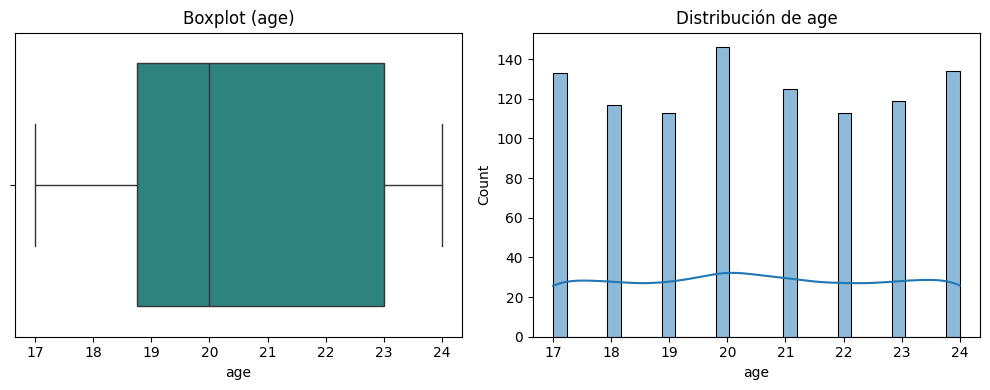

/tmp/ipykernel_2609/1104437566.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_habits[col], palette="viridis")
/tmp/ipykernel_2609/1104437566.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_habits[col], bins=30, palette="viridis", kde=True)


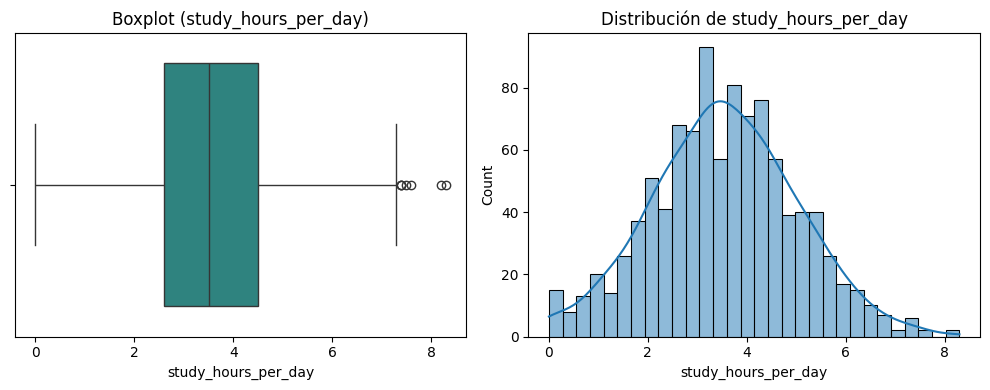

/tmp/ipykernel_2609/1104437566.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_habits[col], palette="viridis")
/tmp/ipykernel_2609/1104437566.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_habits[col], bins=30, palette="viridis", kde=True)


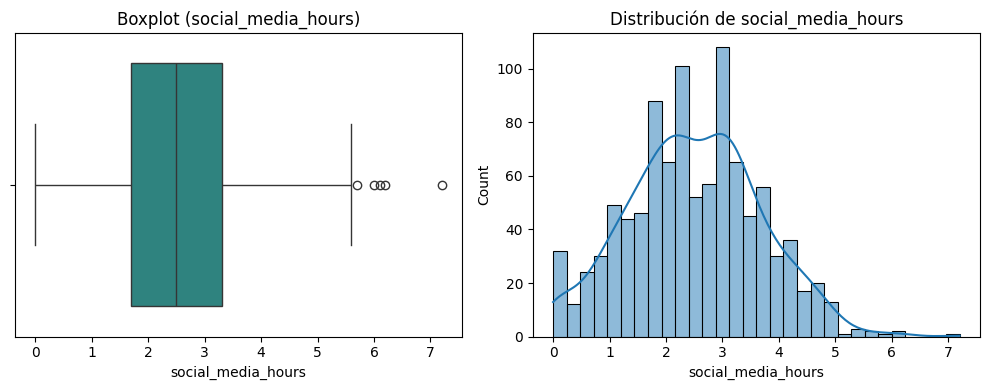

/tmp/ipykernel_2609/1104437566.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_habits[col], palette="viridis")
/tmp/ipykernel_2609/1104437566.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_habits[col], bins=30, palette="viridis", kde=True)


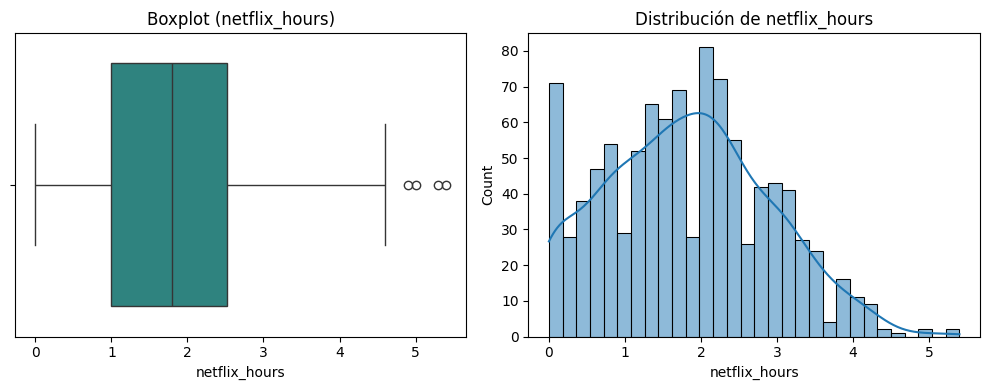

/tmp/ipykernel_2609/1104437566.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_habits[col], palette="viridis")
/tmp/ipykernel_2609/1104437566.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_habits[col], bins=30, palette="viridis", kde=True)


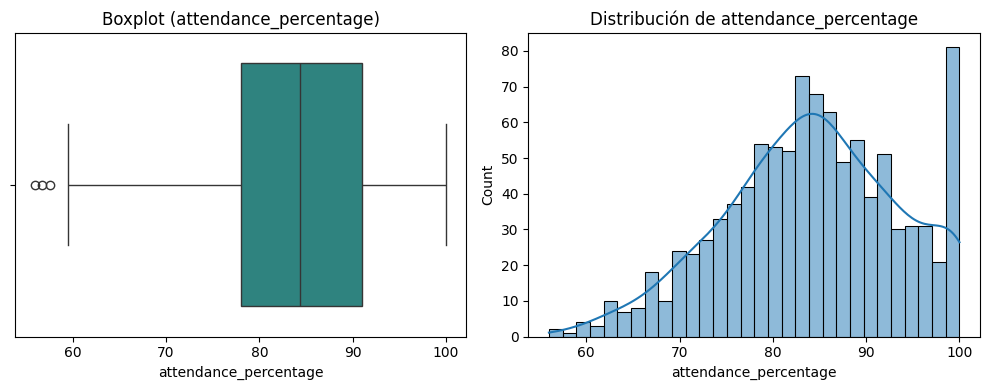

/tmp/ipykernel_2609/1104437566.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_habits[col], palette="viridis")
/tmp/ipykernel_2609/1104437566.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_habits[col], bins=30, palette="viridis", kde=True)


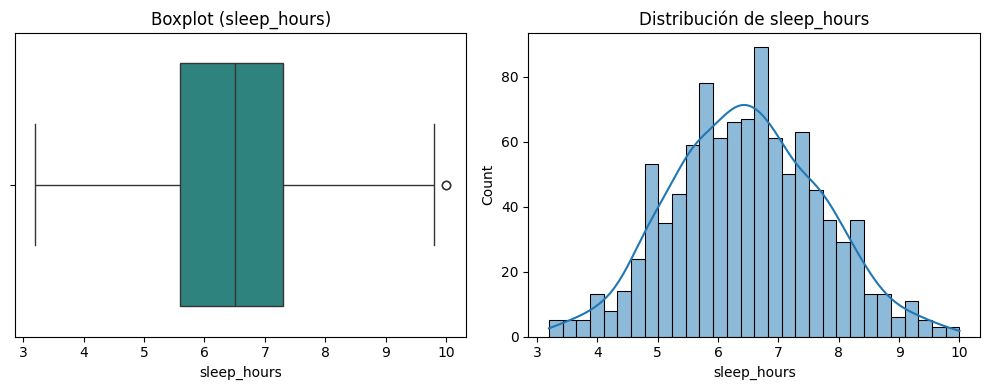

/tmp/ipykernel_2609/1104437566.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_habits[col], palette="viridis")
/tmp/ipykernel_2609/1104437566.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_habits[col], bins=30, palette="viridis", kde=True)


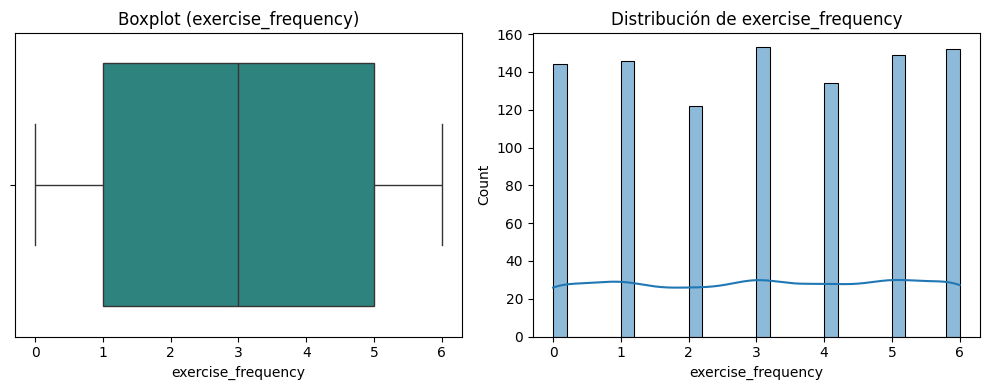

/tmp/ipykernel_2609/1104437566.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_habits[col], palette="viridis")
/tmp/ipykernel_2609/1104437566.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_habits[col], bins=30, palette="viridis", kde=True)


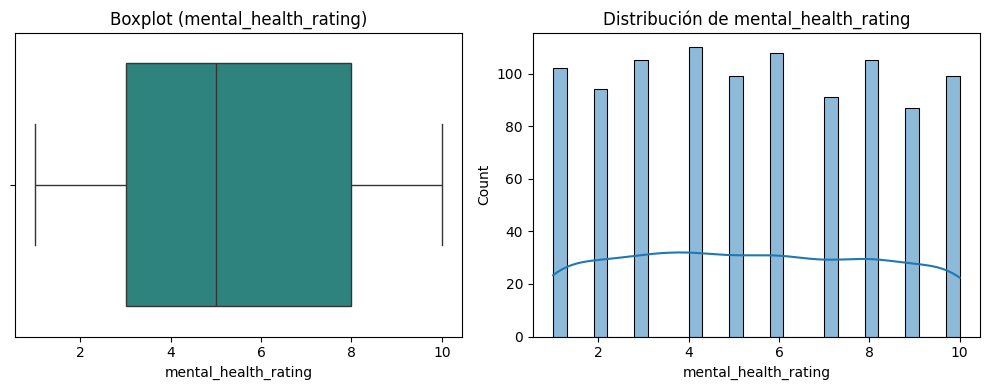

/tmp/ipykernel_2609/1104437566.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_habits[col], palette="viridis")
/tmp/ipykernel_2609/1104437566.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_habits[col], bins=30, palette="viridis", kde=True)


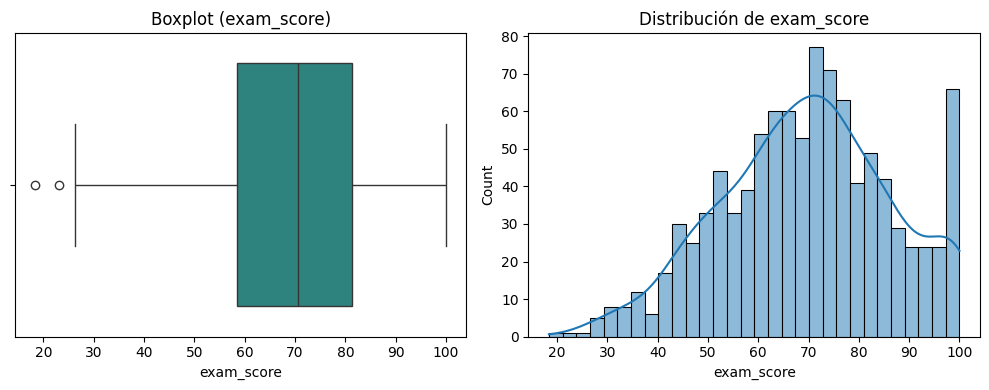

In [22]:
# HISTOGRAMA Y GRAFICO  DE CAJA Y BIGOTES PARA VARIABLES CUANTITATIVA

# Lista de columnas cuantitativas a analizar
cols_cuantitativas = df_habits.select_dtypes(include=['int64', 'float64']).columns.tolist()
#cols_cuantitativas = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours",
#                      "attendande_percentage", "sleep_hours", "exercise_frequency", "mental_health_rating ",
#                      "exam_score"
#                      ]

# Iterar sobre cada columna y graficar
for col in cols_cuantitativas:
    plt.figure(figsize=(10, 4))  # tamaño de la figura

    #Gráfico de caja y bigotes
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df_habits[col], palette="viridis")
    plt.title(f"Boxplot ({col})")

    # Gráfico para el histograma identificar sesgos o valores atípicos (outliers)
    plt.subplot(1, 2, 2)
    sns.histplot(df_habits[col], bins=30, palette="viridis", kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2609/1902325529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


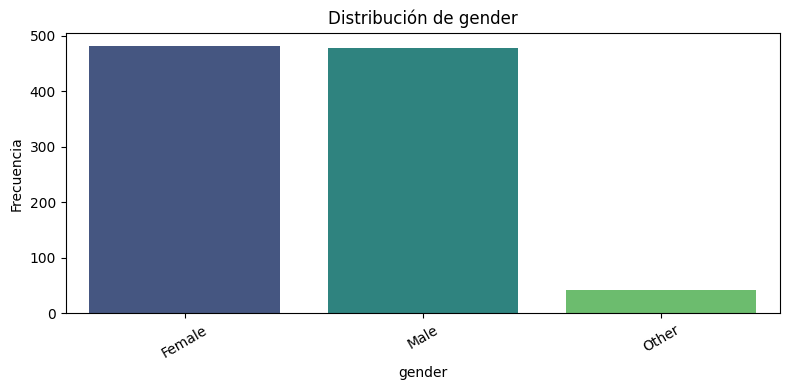

/tmp/ipykernel_2609/1902325529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


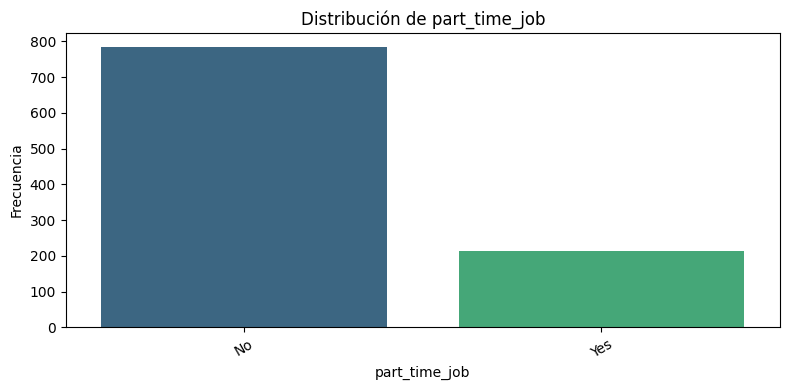

/tmp/ipykernel_2609/1902325529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


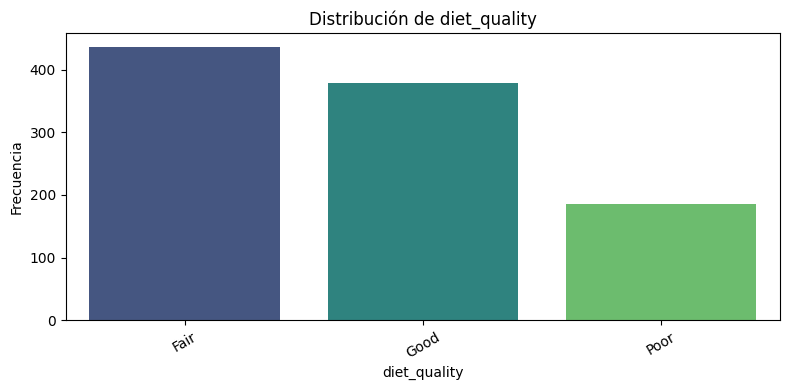

/tmp/ipykernel_2609/1902325529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


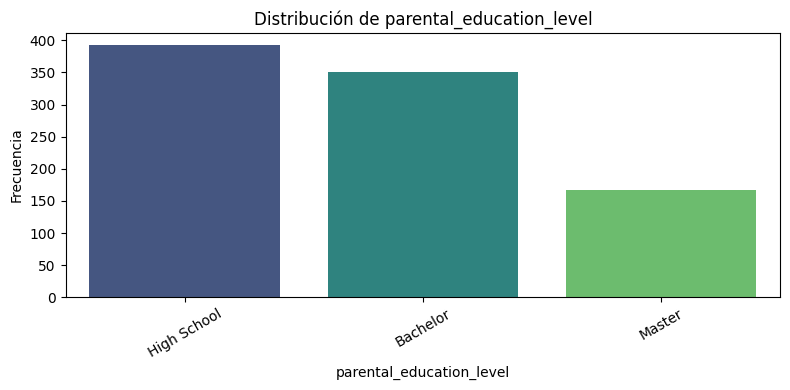

/tmp/ipykernel_2609/1902325529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


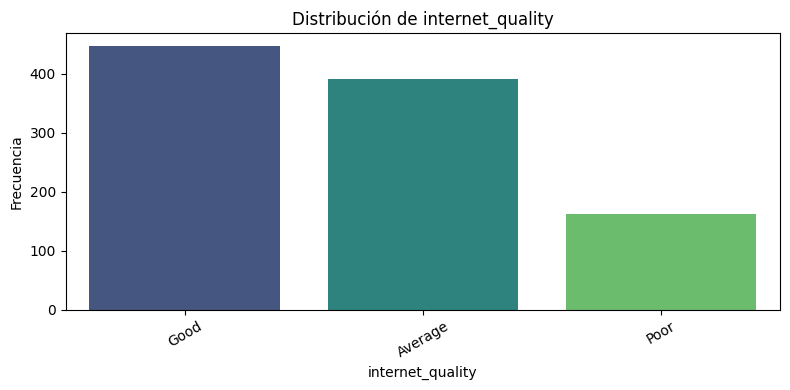

/tmp/ipykernel_2609/1902325529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


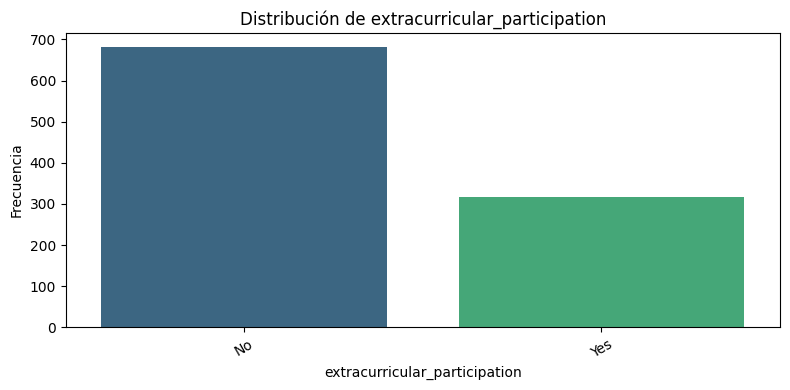

In [18]:
 GRAFICO  DE BARRAS PARA VARIABLES CUALITATIVA

# Lista de columnas cuantitativas a analizar
cols_cualitativas = df_habits.select_dtypes(include=['object', 'category']).columns.tolist()

# Iterar sobre cada columna y graficar
for col in cols_cualitativas:
    plt.figure(figsize=(8, 4))

    # Conteo de categorías
    counts = df_habits[col].value_counts()

    # Gráfico de barras
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    plt.title(f"Distribución de {col}")
    plt.ylabel("Frecuencia")
    plt.xlabel(col)
    plt.xticks(rotation=30)  # rotar etiquetas si son largas

    plt.tight_layout()
    plt.show()

#SEGUNDA SECCIÓN

## UMA

